# Hypothesis Testing: Does Education Level Predict AI Exposure?

Question: Do census tracts with high bachelor's degree attainment have significantly higher AI exposure than tracts with low attainment?

## Load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

df = pd.read_csv('data/features.csv')

# Clean: drop zero-exposure rows and NaNs (same as data_analysis.ipynb)
df = df[df['AI Exposure Score (0-0.29)'] != 0].dropna()

print(f"Total census tracts: {len(df):,}")
df[['pct_bachelors_plus', 'AI Exposure Score (0-0.29)']].describe().round(4)

Total census tracts: 80,679


,pct_bachelors_plus,AI Exposure Score (0-0.29)
count,80679.0000,80679.0000
mean,0.3444,0.1792
std,0.1990,0.0250
min,0.0000,0.0822
25%,0.1884,0.1627
50%,0.2998,0.1780
75%,0.4724,0.1947
max,1.0000,0.2830


## Split data

We split tracts into **top 25%** and **bottom 25%** by bachelor's degree attainment.


In [4]:
q25 = df['pct_bachelors_plus'].quantile(0.25)
q75 = df['pct_bachelors_plus'].quantile(0.75)

low_ed  = df[df['pct_bachelors_plus'] <= q25]['AI Exposure Score (0-0.29)']
high_ed = df[df['pct_bachelors_plus'] >= q75]['AI Exposure Score (0-0.29)']

## Hypotheses

**Null hypothesis (H0):** High-education and low-education tracts have the same AI exposure distribution. Any observed difference is due to random chance.

**Alternative hypothesis (H1):** High-education tracts have higher AI exposure than low-education tracts.

Significance level: **α = 0.05**. If our p-value is below 0.05, we reject the null hypothesis.

## Mann-Whitney U Test

A Mann-Whitney makes no assumption about the distribution shape, which is why we're using it here instead of a t-test.

In [7]:
stat, p_value = mannwhitneyu(high_ed, low_ed, alternative='greater')

alpha = 0.05

print("Mann-Whitney U Test Results")
print(f"U statistic: {stat:,.0f}")
print(f"p-value: {p_value:.2e}")
print(f"alpha: {alpha}")

if p_value < alpha:
    print("Conclusion: Reject H0")
    print("High-education tracts have significantly higher AI exposure (p < 0.05).")
else:
    print("Conclusion : Fail to reject H0")
    print("No significant difference detected (p >= 0.05).")

Mann-Whitney U Test Results
U statistic: 265,890,684
p-value: 0.00e+00
alpha: 0.05
Conclusion: Reject H0
High-education tracts have significantly higher AI exposure (p < 0.05).


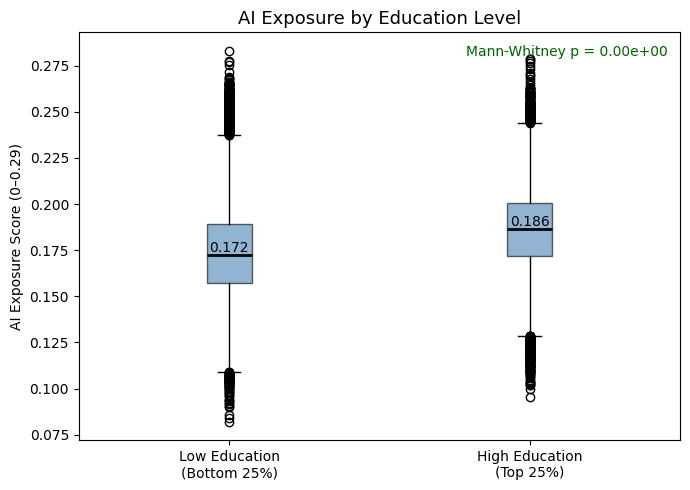

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [low_ed, high_ed],
    labels=['Low Education\n(Bottom 25%)', 'High Education\n(Top 25%)'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

med_low = np.median(low_ed)
med_high = np.median(high_ed)
ax.text(1, med_low, f'{med_low:.3f}', ha='center', va='bottom')
ax.text(2, med_high, f'{med_high:.3f}', ha='center', va='bottom')

ax.set_title('AI Exposure by Education Level', fontsize=13)
ax.set_ylabel('AI Exposure Score (0–0.29)')
ax.text(0.98, 0.97, f'Mann-Whitney p = {p_value:.2e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='darkgreen')

plt.tight_layout()
plt.show()

In [12]:
# Rank-biserial correlation: effect size for Mann-Whitney
n1, n2 = len(high_ed), len(low_ed)
rank_biserial = (2 * stat) / (n1 * n2) - 1
print(f"Effect size (rank-biserial r): {rank_biserial:.4f}")

Effect size (rank-biserial r): 0.3071


Since we have 80,000+ observations, the Mann-Whitney test has large statistical power and will flag trivially small differences as significant. As you can see in the box plot above, the medians are roughly 0.172 vs 0.186, which is a a difference of about 0.014 on a 0–0.29 scale. The test says p ≈ 0, but that doesn't necessarily mean the effect is meaningful.

A rank-biserial of 0.31 meams that the difference is statistically significant (census tracts where more residents hold bachelor's degrees are exposed to significantly higher levels of AI adoption in the workforce) but modest. High-education tracts score meaningfully higher on AI exposure, but education alone explains little of the variance in AI exposure.